# Predikcija kategorije proizvoda na osnovu naslova

**Autor:** Stefan Stojanović

## Cilj projekta

Cilj ovog projekta je razvoj modela mašinskog učenja koji na osnovu naziva proizvoda automatski predlaže odgovarajuću kategoriju.

Projekat obuhvata analizu i čišćenje podataka, inženjering karakteristika, treniranje i poređenje više modela, evaluaciju najboljeg rešenja i njegovo čuvanje za kasniju upotrebu.

Razvijeni model može doprineti bržem unosu proizvoda, smanjenju broja grešaka pri ručnoj kategorizaciji i jednostavnijem radu zaposlenih na platformi za online trgovinu.

## 1. Uvoz potrebnih biblioteka

U ovom delu uvozimo biblioteke potrebne za rad sa podacima, vizualizaciju rezultata i razvoj modela mašinskog učenja.

In [1]:
# Biblioteke za učitavanje i obradu podataka
import pandas as pd
import numpy as np

# Biblioteke za vizualizaciju
import matplotlib.pyplot as plt
import seaborn as sns

# Pomoćne biblioteke
import re
import time
from pathlib import Path

# Podešavanje prikaza tabela
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Podešavanje izgleda grafikona
sns.set_theme(style="whitegrid")

print("Sve biblioteke su uspešno učitane.")

Sve biblioteke su uspešno učitane.


## 2. Učitavanje i početni pregled podataka

Učitavamo skup podataka iz foldera `data` i proveravamo njegove dimenzije i prve redove. Putanja je podešena tako da sveska može da radi i kada se pokrene iz glavnog foldera projekta i kada se pokrene iz foldera `notebooks`.

In [2]:
# Moguće putanje do skupa podataka
possible_paths = [
    Path("../data/products.csv"),
    Path("data/products.csv")
]

# Pronalazimo prvu postojeću putanju
data_path = next((path for path in possible_paths if path.exists()), None)

# Zaustavljamo izvršavanje uz jasnu poruku ako fajl nije pronađen
if data_path is None:
    raise FileNotFoundError(
        "Fajl products.csv nije pronađen u folderu data."
    )

# Učitavanje podataka
df = pd.read_csv(data_path)

print(f"Dataset je uspešno učitan sa putanje: {data_path}")
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

# Prikaz prvih pet redova
df.head()

Dataset je uspešno učitan sa putanje: ..\data\products.csv
Broj redova: 35311
Broj kolona: 8


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim free smartphone in gold,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked sim free,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


### 2.1. Struktura skupa i tipovi podataka

Proveravamo tačne nazive kolona, tipove podataka i broj popunjenih vrednosti. Ovaj pregled pomaže da otkrijemo skrivene razmake u nazivima kolona i kolone koje sadrže nedostajuće podatke.

In [3]:
# Prikaz tačnih naziva kolona
print("Nazivi kolona:")
for column in df.columns:
    print(repr(column))

print("\nOsnovne informacije o skupu podataka:")
df.info()

Nazivi kolona:
'product ID'
'Product Title'
'Merchant ID'
' Category Label'
'_Product Code'
'Number_of_Views'
'Merchant Rating'
' Listing Date  '

Osnovne informacije o skupu podataka:
<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  str    
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  str    
 4   _Product Code    35216 non-null  str    
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


### 2.2. Nedostajuće vrednosti i duplikati

Proveravamo broj i procenat nedostajućih vrednosti u svakoj koloni, kao i postojanje potpuno dupliranih redova. Ovi rezultati će odrediti naredne korake čišćenja podataka.

In [4]:
# Broj nedostajućih vrednosti po kolonama
missing_values = df.isna().sum()

# Procenat nedostajućih vrednosti po kolonama
missing_percentage = (missing_values / len(df) * 100).round(2)

# Tabela sa rezultatima
missing_summary = pd.DataFrame({
    "Broj nedostajućih": missing_values,
    "Procenat (%)": missing_percentage
})

print("Pregled nedostajućih vrednosti:")
display(missing_summary)

# Provera potpuno dupliranih redova
duplicate_rows = df.duplicated().sum()

print(f"\nBroj potpuno dupliranih redova: {duplicate_rows}")

Pregled nedostajućih vrednosti:


,Broj nedostajućih,Procenat (%)
product ID,0,0.00
Product Title,172,0.49
Merchant ID,0,0.00
Category Label,44,0.12
_Product Code,95,0.27
Number_of_Views,14,0.04
Merchant Rating,170,0.48
Listing Date,59,0.17



Broj potpuno dupliranih redova: 0


### 2.3. Analiza ciljne promenljive

Ciljna promenljiva je kategorija proizvoda. Proveravamo broj jedinstvenih kategorija, njihove nazive i broj proizvoda u svakoj kategoriji. Posebnu pažnju obraćamo na različito napisane oznake koje možda predstavljaju istu kategoriju.

In [5]:
# Pronalaženje kolone sa kategorijama bez oslanjanja na skrivene razmake
category_column = next(
    column for column in df.columns
    if column.strip() == "Category Label"
)

# Broj jedinstvenih nepraznih kategorija
number_of_categories = df[category_column].nunique()

print(f"Broj jedinstvenih nepraznih kategorija: {number_of_categories}")

print("\nTačni nazivi kategorija:")
for category in sorted(df[category_column].dropna().unique()):
    print(repr(category))

print("\nBroj proizvoda po kategorijama:")
display(df[category_column].value_counts(dropna=False).to_frame("Broj proizvoda"))

Broj jedinstvenih nepraznih kategorija: 13

Tačni nazivi kategorija:
'CPU'
'CPUs'
'Digital Cameras'
'Dishwashers'
'Freezers'
'Fridge Freezers'
'Fridges'
'Microwaves'
'Mobile Phone'
'Mobile Phones'
'TVs'
'Washing Machines'
'fridge'

Broj proizvoda po kategorijama:


,Broj proizvoda
Category Label,
Fridge Freezers,5495
Washing Machines,4036
Mobile Phones,4020
CPUs,3771
TVs,3564
Fridges,3457
Dishwashers,3418
Digital Cameras,2696
Microwaves,2338


## 3. Čišćenje i standardizacija podataka

Tokom početnog pregleda pronađeni su suvišni razmaci u nazivima kolona, prazni naslovi i kategorije, kao i različito napisane oznake za iste kategorije.

Nazive kolona standardizujemo radi jednostavnijeg i pouzdanijeg rada. Uklanjamo samo redove kojima nedostaje naslov proizvoda ili ciljna kategorija, jer su upravo te dve kolone neophodne za treniranje modela.

Nedostajuće vrednosti u ostalim kolonama ne zahtevaju uklanjanje redova, pošto model kategoriju predviđa na osnovu naslova proizvoda.

In [6]:
# Kreiranje kopije originalnog skupa
df_clean = df.copy()

# Standardizacija naziva kolona
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Broj redova pre čišćenja
initial_row_count = len(df_clean)

# Uklanjanje redova bez naslova ili kategorije
df_clean = df_clean.dropna(
    subset=["product_title", "category_label"]
).copy()

# Uklanjanje suvišnih razmaka iz tekstualnih vrednosti
df_clean["product_title"] = (
    df_clean["product_title"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df_clean["category_label"] = df_clean["category_label"].str.strip()

# Objedinjavanje različitih oznaka koje predstavljaju iste kategorije
category_mapping = {
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
    "fridge": "Fridges"
}

df_clean["category_label"] = (
    df_clean["category_label"]
    .replace(category_mapping)
)

# Uklanjanje eventualnih naslova koji sadrže samo razmake
df_clean = df_clean[
    df_clean["product_title"].str.len() > 0
].copy()

# Resetovanje indeksa nakon uklanjanja redova
df_clean = df_clean.reset_index(drop=True)

removed_row_count = initial_row_count - len(df_clean)

print("Standardizovani nazivi kolona:")
print(df_clean.columns.tolist())

print(f"\nBroj redova pre čišćenja: {initial_row_count}")
print(f"Broj uklonjenih redova: {removed_row_count}")
print(f"Broj redova nakon čišćenja: {len(df_clean)}")
print(f"Broj kategorija nakon standardizacije: {df_clean['category_label'].nunique()}")

Standardizovani nazivi kolona:
['product_id', 'product_title', 'merchant_id', 'category_label', 'product_code', 'number_of_views', 'merchant_rating', 'listing_date']

Broj redova pre čišćenja: 35311
Broj uklonjenih redova: 215
Broj redova nakon čišćenja: 35096
Broj kategorija nakon standardizacije: 10


### 3.1. Analiza ponovljenih i konfliktnih naslova

Isti proizvod može biti unet više puta, zbog čega proveravamo ponovljene normalizovane naslove. Posebno proveravamo slučajeve u kojima je potpuno isti naslov povezan sa različitim kategorijama.

Takvi konflikti mogu zbuniti model, jer isti ulaz tada ima više različitih ciljnih vrednosti. Normalizovana verzija naslova koristi se samo za otkrivanje ponavljanja i konflikata.

In [7]:
# Kreiranje normalizovane verzije naslova
df_clean["normalized_title"] = (
    df_clean["product_title"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Broj dodatnih pojavljivanja već viđenih naslova
duplicate_title_count = df_clean["normalized_title"].duplicated().sum()

# Broj svih redova koji pripadaju ponovljenim naslovima
rows_with_duplicate_titles = (
    df_clean["normalized_title"]
    .duplicated(keep=False)
    .sum()
)

# Broj različitih kategorija za svaki normalizovani naslov
categories_per_title = (
    df_clean.groupby("normalized_title")["category_label"]
    .nunique()
)

# Naslovi povezani sa više različitih kategorija
conflicting_titles = categories_per_title[
    categories_per_title > 1
].index

conflicting_rows = df_clean[
    df_clean["normalized_title"].isin(conflicting_titles)
].sort_values("normalized_title")

print(f"Broj dodatnih pojavljivanja ponovljenih naslova: {duplicate_title_count}")
print(f"Broj svih redova sa ponovljenim naslovima: {rows_with_duplicate_titles}")
print(f"Broj naslova povezanih sa više kategorija: {len(conflicting_titles)}")
print(f"Broj redova obuhvaćenih konfliktima: {len(conflicting_rows)}")

print("\nPrimeri konfliktnih naslova:")
display(
    conflicting_rows[
        ["product_title", "category_label"]
    ].head(20)
)

Broj dodatnih pojavljivanja ponovljenih naslova: 4272
Broj svih redova sa ponovljenim naslovima: 7424
Broj naslova povezanih sa više kategorija: 2
Broj redova obuhvaćenih konfliktima: 4

Primeri konfliktnih naslova:


,product_title,category_label
31510,blomberg kgm9550 fridge freezer,Fridge Freezers
34981,blomberg kgm9550 fridge freezer,Fridges
23524,bosch kur15a50gb integrated undercounter fridge,Washing Machines
31538,bosch kur15a50gb integrated undercounter fridge,Fridges


### 3.2. Uklanjanje konfliktnih i ponovljenih naslova

Pronađena su dva normalizovana naslova povezana sa različitim kategorijama. Pošto na osnovu dostupnih podataka nije moguće pouzdano odrediti ispravnu oznaku, uklanjamo sve redove povezane sa tim naslovima.

Nakon toga svaki ponovljeni normalizovani naslov zadržavamo samo jednom. Identični naslovi ne pružaju novu tekstualnu informaciju modelu, a njihovo pojavljivanje i u trening i u test skupu moglo bi veštački povećati rezultat evaluacije.

In [8]:
# Broj redova pre uklanjanja konflikata i ponavljanja
rows_before_deduplication = len(df_clean)

# Uklanjanje svih redova sa konfliktnim naslovima
df_clean = df_clean[
    ~df_clean["normalized_title"].isin(conflicting_titles)
].copy()

rows_after_conflict_removal = len(df_clean)
removed_conflicting_rows = (
    rows_before_deduplication - rows_after_conflict_removal
)

# Zadržavanje samo jednog reda za svaki normalizovani naslov
df_clean = df_clean.drop_duplicates(
    subset="normalized_title",
    keep="first"
).copy()

removed_duplicate_rows = (
    rows_after_conflict_removal - len(df_clean)
)

# Resetovanje indeksa
df_clean = df_clean.reset_index(drop=True)

print(f"Uklonjeni konfliktni redovi: {removed_conflicting_rows}")
print(f"Uklonjeni ponovljeni redovi: {removed_duplicate_rows}")
print(f"Konačan broj redova: {len(df_clean)}")
print(
    "Preostali ponovljeni naslovi:",
    df_clean["normalized_title"].duplicated().sum()
)
print(
    "Nedostajući naslovi:",
    df_clean["product_title"].isna().sum()
)
print(
    "Nedostajuće kategorije:",
    df_clean["category_label"].isna().sum()
)
print(
    "Broj kategorija:",
    df_clean["category_label"].nunique()
)

Uklonjeni konfliktni redovi: 4
Uklonjeni ponovljeni redovi: 4270
Konačan broj redova: 30822
Preostali ponovljeni naslovi: 0
Nedostajući naslovi: 0
Nedostajuće kategorije: 0
Broj kategorija: 10


## 4. Istraživačka analiza podataka

### 4.1. Raspodela proizvoda po kategorijama

Proveravamo broj i procenat proizvoda u svakoj kategoriji. Ova analiza pokazuje da li su kategorije približno ravnomerno zastupljene i pomaže pri pravilnoj podeli podataka na trening i test skup.

,Broj proizvoda,Procenat (%)
category_label,,
Fridge Freezers,4808,15.60
Mobile Phones,3662,11.88
Washing Machines,3402,11.04
TVs,3275,10.63
Fridges,3188,10.34
CPUs,3043,9.87
Dishwashers,3042,9.87
Digital Cameras,2405,7.80
Microwaves,2094,6.79


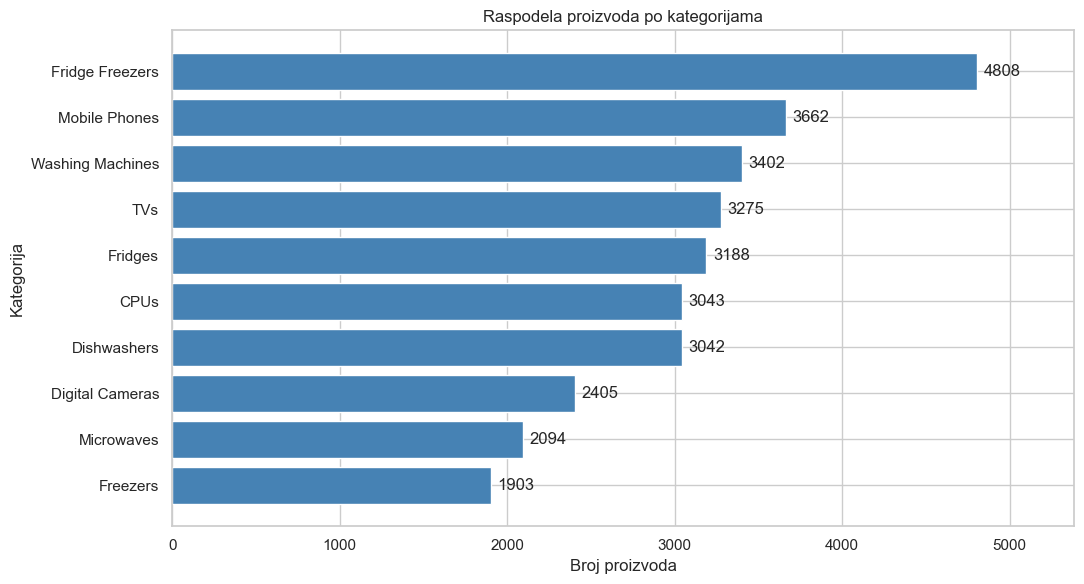

In [9]:
# Broj proizvoda po kategorijama
category_counts = (
    df_clean["category_label"]
    .value_counts()
    .sort_values(ascending=False)
)

# Procenat proizvoda po kategorijama
category_percentages = (
    df_clean["category_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Tabela raspodele
category_distribution = pd.DataFrame({
    "Broj proizvoda": category_counts,
    "Procenat (%)": category_percentages
})

display(category_distribution)

# Priprema podataka za horizontalni grafikon
plot_counts = category_counts.sort_values()

plt.figure(figsize=(11, 6))

bars = plt.barh(
    plot_counts.index,
    plot_counts.values,
    color="steelblue"
)

# Dodavanje broja proizvoda pored svake trake
for bar in bars:
    plt.text(
        bar.get_width() + 40,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.title("Raspodela proizvoda po kategorijama")
plt.xlabel("Broj proizvoda")
plt.ylabel("Kategorija")
plt.xlim(0, plot_counts.max() * 1.12)
plt.tight_layout()
plt.show()

#### Zapažanje

Najzastupljenija kategorija je `Fridge Freezers` sa 4.808 proizvoda, odnosno 15,60% očišćenog skupa. Najmanje je zastupljena kategorija `Freezers` sa 1.903 proizvoda, odnosno 6,17%.

Raspodela nije potpuno ujednačena, ali sve kategorije imaju dovoljan broj primera za treniranje. Prilikom podele koristićemo stratifikaciju kako bismo sačuvali približno isti odnos kategorija u trening i test skupu. Pored ukupne tačnosti, pratićemo macro F1 rezultat kako bi svaka kategorija imala jednak značaj u evaluaciji.

## 5. Inženjering karakteristika

### 5.1. Kreiranje dodatnih karakteristika iz naslova

Pored samih reči iz naslova, kreiramo dodatne numeričke karakteristike koje mogu sadržati korisne informacije za razlikovanje kategorija:

- broj karaktera;
- broj reči;
- broj cifara;
- prisustvo broja;
- broj specijalnih znakova;
- dužina najduže reči;
- broj reči napisanih velikim slovima.

Njihovu korisnost ćemo kasnije proveriti poređenjem modela, umesto da unapred pretpostavimo da poboljšavaju rezultat.

In [10]:
# Broj karaktera u naslovu
df_clean["title_length"] = (
    df_clean["product_title"].str.len()
)

# Broj reči u naslovu
df_clean["word_count"] = (
    df_clean["product_title"].str.split().str.len()
)

# Broj cifara u naslovu
df_clean["digit_count"] = (
    df_clean["product_title"]
    .str.count(r"\d")
)

# Informacija da li naslov sadrži najmanje jednu cifru
df_clean["contains_number"] = (
    df_clean["product_title"]
    .str.contains(r"\d", regex=True)
    .astype(int)
)

# Broj specijalnih znakova
df_clean["special_char_count"] = (
    df_clean["product_title"]
    .str.count(r"[^A-Za-z0-9\s]")
)

# Dužina najduže reči
df_clean["longest_word_length"] = (
    df_clean["product_title"]
    .str.split()
    .apply(lambda words: max(len(word) for word in words))
)

# Broj reči napisanih velikim slovima
df_clean["uppercase_word_count"] = (
    df_clean["product_title"]
    .str.split()
    .apply(lambda words: sum(word.isupper() for word in words))
)

engineered_features = [
    "title_length",
    "word_count",
    "digit_count",
    "contains_number",
    "special_char_count",
    "longest_word_length",
    "uppercase_word_count"
]

print("Kreirane dodatne karakteristike:")
print(engineered_features)

display(
    df_clean[engineered_features]
    .describe()
    .round(2)
)

Kreirane dodatne karakteristike:
['title_length', 'word_count', 'digit_count', 'contains_number', 'special_char_count', 'longest_word_length', 'uppercase_word_count']


,title_length,word_count,digit_count,contains_number,special_char_count,longest_word_length,uppercase_word_count
count,30822.00,30822.00,30822.00,30822.00,30822.00,30822.00,30822.0
mean,52.76,8.65,6.82,0.97,0.29,9.79,0.0
std,22.62,4.22,4.43,0.18,0.62,2.64,0.0
min,5.00,1.00,0.00,0.00,0.00,2.00,0.0
25%,38.00,6.00,4.00,1.00,0.00,8.00,0.0
50%,51.00,8.00,6.00,1.00,0.00,10.00,0.0
75%,65.00,11.00,9.00,1.00,0.00,11.00,0.0
max,200.00,37.00,54.00,1.00,9.00,33.00,0.0


#### Početno zapažanje o dodatnim karakteristikama

Karakteristika `uppercase_word_count` ima vrednost nula za svaki proizvod. To pokazuje da su naslovi u skupu već zapisani malim slovima, zbog čega ova karakteristika ne sadrži korisnu informaciju i neće biti uključena u modeliranje.

Gotovo svi naslovi sadrže najmanje jednu cifru, pa karakteristika `contains_number` ima malu varijaciju. Njenu stvarnu vrednost proverićemo eksperimentalnim poređenjem modela.

Preostale karakteristike pokazuju dovoljnu varijaciju za dalju analizu.

### 5.2. Poređenje karakteristika između kategorija

Poredimo prosečnu dužinu naslova, broj reči, cifara, specijalnih znakova i dužinu najduže reči između kategorija. Primetne razlike mogu pokazati da dodatne numeričke karakteristike imaju vrednost za klasifikaciju.

,title_length,word_count,digit_count,contains_number,special_char_count,longest_word_length
category_label,,,,,,
CPUs,68.64,12.85,12.61,1.00,1.03,9.42
Fridge Freezers,55.12,8.20,5.61,0.97,0.23,10.29
TVs,53.99,10.10,9.35,0.99,0.24,10.18
Washing Machines,53.46,7.93,7.73,0.96,0.13,10.37
Microwaves,51.66,7.62,5.90,0.96,0.10,10.30
Dishwashers,50.16,6.79,5.48,0.96,0.06,11.06
Digital Cameras,49.31,9.52,5.82,0.98,0.49,7.75
Freezers,48.59,7.19,5.27,0.96,0.09,10.42
Fridges,48.55,7.54,5.23,0.97,0.07,10.02


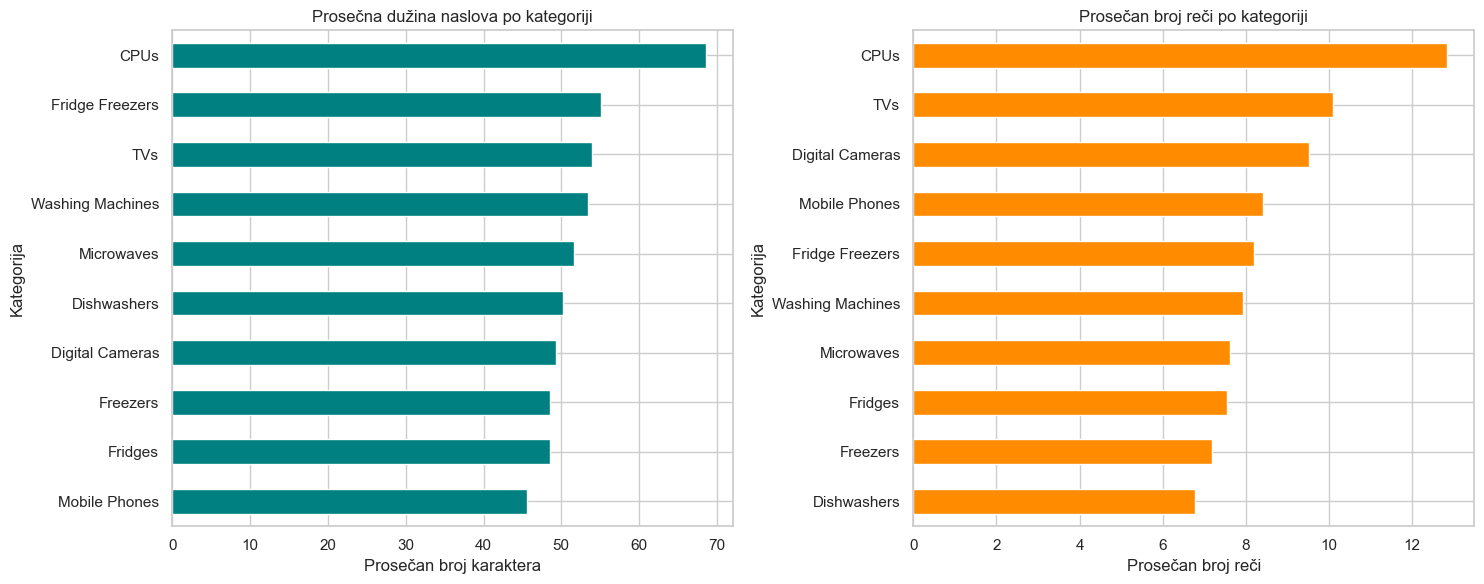

In [11]:
# Karakteristike koje imaju varijaciju
features_for_analysis = [
    "title_length",
    "word_count",
    "digit_count",
    "contains_number",
    "special_char_count",
    "longest_word_length"
]

# Prosečne vrednosti po kategorijama
feature_means_by_category = (
    df_clean
    .groupby("category_label")[features_for_analysis]
    .mean()
    .round(2)
    .sort_values("title_length", ascending=False)
)

display(feature_means_by_category)

# Vizualizacija dve lako razumljive karakteristike
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

feature_means_by_category["title_length"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="teal"
)
axes[0].set_title("Prosečna dužina naslova po kategoriji")
axes[0].set_xlabel("Prosečan broj karaktera")
axes[0].set_ylabel("Kategorija")

feature_means_by_category["word_count"].sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Prosečan broj reči po kategoriji")
axes[1].set_xlabel("Prosečan broj reči")
axes[1].set_ylabel("Kategorija")

plt.tight_layout()
plt.show()

#### Zaključak o dodatnim karakteristikama

Rezultati pokazuju primetne razlike između pojedinih kategorija. Naslovi procesora (`CPUs`) u proseku su najduži, sadrže najviše reči, cifara i specijalnih znakova. Naslovi mobilnih telefona imaju najmanju prosečnu dužinu, dok digitalni fotoaparati imaju najkraću prosečnu najdužu reč.

Ove razlike pokazuju da dodatne numeričke karakteristike mogu sadržati korisne informacije. Ipak, neke kategorije imaju međusobno slične vrednosti, pa ove karakteristike ne mogu zameniti analizu samog teksta. Njihovu korisnost ćemo proveriti poređenjem osnovnog tekstualnog modela sa unapređenim modelom koji kombinuje tekstualne i numeričke karakteristike.

Karakteristika `uppercase_word_count` neće biti korišćena jer nema varijaciju.

## 6. Priprema podataka za modeliranje

### 6.1. Definisanje ulaznih i ciljnih podataka

Ulazni podaci obuhvataju naslov proizvoda i odabrane numeričke karakteristike izvedene iz naslova. Ciljna promenljiva je standardizovana kategorija proizvoda.

Podatke delimo na 80% za treniranje i 20% za testiranje. Koristimo stratifikaciju kako bi odnos svih kategorija ostao približno jednak u oba skupa. Fiksiranje parametra `random_state` omogućava ponavljanje istog eksperimenta.

In [12]:
from sklearn.model_selection import train_test_split

# Karakteristike koje ćemo koristiti tokom eksperimenata
model_feature_columns = [
    "product_title",
    "title_length",
    "word_count",
    "digit_count",
    "contains_number",
    "special_char_count",
    "longest_word_length"
]

# Ulazni podaci i ciljna promenljiva
X = df_clean[model_feature_columns].copy()
y = df_clean["category_label"].copy()

# Stratifikovana podela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Ukupan broj proizvoda: {len(X)}")
print(f"Broj proizvoda za treniranje: {len(X_train)}")
print(f"Broj proizvoda za testiranje: {len(X_test)}")
print(f"Broj kategorija u trening skupu: {y_train.nunique()}")
print(f"Broj kategorija u test skupu: {y_test.nunique()}")

# Poređenje procentualne raspodele kategorija
distribution_comparison = pd.DataFrame({
    "Ceo skup (%)": y.value_counts(normalize=True).mul(100),
    "Trening skup (%)": y_train.value_counts(normalize=True).mul(100),
    "Test skup (%)": y_test.value_counts(normalize=True).mul(100)
}).round(2).sort_index()

display(distribution_comparison)

Ukupan broj proizvoda: 30822
Broj proizvoda za treniranje: 24657
Broj proizvoda za testiranje: 6165
Broj kategorija u trening skupu: 10
Broj kategorija u test skupu: 10


,Ceo skup (%),Trening skup (%),Test skup (%)
category_label,,,
CPUs,9.87,9.87,9.88
Digital Cameras,7.80,7.80,7.80
Dishwashers,9.87,9.87,9.86
Freezers,6.17,6.17,6.18
Fridge Freezers,15.60,15.60,15.60
Fridges,10.34,10.34,10.35
Microwaves,6.79,6.79,6.80
Mobile Phones,11.88,11.88,11.87
TVs,10.63,10.63,10.62


## 7. Treniranje i poređenje modela

### 7.1. Osnovni model – TF-IDF i logistička regresija

Prvi model predstavlja početno rešenje sa kojim ćemo porediti naredne eksperimente. TF-IDF pretvara reči i kombinacije od dve susedne reči iz naslova u numeričke karakteristike, dok logistička regresija vrši višeklasnu klasifikaciju.

Vektorizacija i model povezani su u jedinstven Pipeline. TF-IDF se uči isključivo na trening skupu, čime se sprečava curenje informacija iz test skupa.

Pored ukupne tačnosti pratimo macro F1, koji svim kategorijama daje jednak značaj, i weighted F1, koji uzima u obzir broj proizvoda u svakoj kategoriji.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Pipeline osnovnog modela
logistic_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Treniranje modela i merenje vremena
start_time = time.time()

logistic_pipeline.fit(
    X_train["product_title"],
    y_train
)

logistic_training_time = time.time() - start_time

# Predikcije na test skupu
logistic_predictions = logistic_pipeline.predict(
    X_test["product_title"]
)

# Izračunavanje metrika
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_macro_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro"
)

logistic_weighted_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

print("Logistic Regression – rezultati")
print("-" * 40)
print(f"Vreme treniranja: {logistic_training_time:.2f} sekundi")
print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"Macro F1: {logistic_macro_f1:.4f}")
print(f"Weighted F1: {logistic_weighted_f1:.4f}")

print("\nKlasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression – rezultati
----------------------------------------
Vreme treniranja: 2.63 sekundi
Accuracy: 0.9526
Macro F1: 0.9549
Weighted F1: 0.9527

Klasifikacioni izveštaj:
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       609
 Digital Cameras       1.00      1.00      1.00       481
     Dishwashers       0.93      0.94      0.93       608
        Freezers       0.96      0.92      0.94       381
 Fridge Freezers       0.91      0.93      0.92       962
         Fridges       0.88      0.88      0.88       638
      Microwaves       1.00      0.94      0.97       419
   Mobile Phones       0.96      0.99      0.98       732
             TVs       0.98      0.99      0.99       655
Washing Machines       0.95      0.94      0.94       680

        accuracy                           0.95      6165
       macro avg       0.96      0.95      0.95      6165
    weighted avg       0.95      0.95      0.95      6165



### 7.2. Drugi model – TF-IDF i Linear SVC

Drugi model koristi iste TF-IDF karakteristike kao osnovni model, ali klasifikaciju vrši pomoću algoritma Linear Support Vector Classification.

Linear SVC je često veoma efikasan za klasifikaciju teksta sa velikim brojem retkih karakteristika. Korišćenje iste vektorizacije omogućava da razliku u rezultatima pripišemo izboru algoritma.

In [14]:
from sklearn.svm import LinearSVC

# Pipeline drugog modela
linear_svc_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            random_state=42
        )
    )
])

# Treniranje modela i merenje vremena
start_time = time.time()

linear_svc_pipeline.fit(
    X_train["product_title"],
    y_train
)

linear_svc_training_time = time.time() - start_time

# Predikcije na test skupu
linear_svc_predictions = linear_svc_pipeline.predict(
    X_test["product_title"]
)

# Izračunavanje metrika
linear_svc_accuracy = accuracy_score(
    y_test,
    linear_svc_predictions
)

linear_svc_macro_f1 = f1_score(
    y_test,
    linear_svc_predictions,
    average="macro"
)

linear_svc_weighted_f1 = f1_score(
    y_test,
    linear_svc_predictions,
    average="weighted"
)

print("Linear SVC – rezultati")
print("-" * 40)
print(f"Vreme treniranja: {linear_svc_training_time:.2f} sekundi")
print(f"Accuracy: {linear_svc_accuracy:.4f}")
print(f"Macro F1: {linear_svc_macro_f1:.4f}")
print(f"Weighted F1: {linear_svc_weighted_f1:.4f}")

print("\nKlasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        linear_svc_predictions,
        zero_division=0
    )
)

Linear SVC – rezultati
----------------------------------------
Vreme treniranja: 0.72 sekundi
Accuracy: 0.9601
Macro F1: 0.9620
Weighted F1: 0.9601

Klasifikacioni izveštaj:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       609
 Digital Cameras       1.00      1.00      1.00       481
     Dishwashers       0.95      0.95      0.95       608
        Freezers       0.95      0.93      0.94       381
 Fridge Freezers       0.91      0.95      0.93       962
         Fridges       0.92      0.90      0.91       638
      Microwaves       0.99      0.95      0.97       419
   Mobile Phones       0.96      1.00      0.98       732
             TVs       1.00      0.99      0.99       655
Washing Machines       0.96      0.94      0.95       680

        accuracy                           0.96      6165
       macro avg       0.96      0.96      0.96      6165
    weighted avg       0.96      0.96      0.96      6165



### 7.3. Treći model – TF-IDF i Multinomial Naive Bayes

Treći eksperiment koristi Multinomial Naive Bayes, algoritam koji je jednostavan, brz i često predstavlja dobru osnovu za klasifikaciju teksta.

Model koristi istu TF-IDF vektorizaciju kao prethodna dva modela. Time nastavljamo kontrolisano poređenje algoritama pod jednakim uslovima.

In [15]:
from sklearn.naive_bayes import MultinomialNB

# Pipeline trećeg modela
naive_bayes_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        MultinomialNB(
            alpha=0.1
        )
    )
])

# Treniranje modela i merenje vremena
start_time = time.time()

naive_bayes_pipeline.fit(
    X_train["product_title"],
    y_train
)

naive_bayes_training_time = time.time() - start_time

# Predikcije na test skupu
naive_bayes_predictions = naive_bayes_pipeline.predict(
    X_test["product_title"]
)

# Izračunavanje metrika
naive_bayes_accuracy = accuracy_score(
    y_test,
    naive_bayes_predictions
)

naive_bayes_macro_f1 = f1_score(
    y_test,
    naive_bayes_predictions,
    average="macro"
)

naive_bayes_weighted_f1 = f1_score(
    y_test,
    naive_bayes_predictions,
    average="weighted"
)

print("Multinomial Naive Bayes – rezultati")
print("-" * 40)
print(f"Vreme treniranja: {naive_bayes_training_time:.2f} sekundi")
print(f"Accuracy: {naive_bayes_accuracy:.4f}")
print(f"Macro F1: {naive_bayes_macro_f1:.4f}")
print(f"Weighted F1: {naive_bayes_weighted_f1:.4f}")

print("\nKlasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        naive_bayes_predictions,
        zero_division=0
    )
)

Multinomial Naive Bayes – rezultati
----------------------------------------
Vreme treniranja: 0.45 sekundi
Accuracy: 0.9619
Macro F1: 0.9634
Weighted F1: 0.9619

Klasifikacioni izveštaj:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       609
 Digital Cameras       1.00      1.00      1.00       481
     Dishwashers       0.91      0.98      0.94       608
        Freezers       0.99      0.88      0.93       381
 Fridge Freezers       0.91      0.94      0.93       962
         Fridges       0.91      0.89      0.90       638
      Microwaves       1.00      0.96      0.98       419
   Mobile Phones       1.00      0.99      0.99       732
             TVs       0.98      1.00      0.99       655
Washing Machines       0.99      0.96      0.97       680

        accuracy                           0.96      6165
       macro avg       0.97      0.96      0.96      6165
    weighted avg       0.96      0.96      0.96      616

### 7.4. Unapređeni model – kombinovane karakteristike i Linear SVC

U ovom eksperimentu proširujemo prostor karakteristika kombinovanjem tri izvora informacija:

1. TF-IDF karakteristike reči i parova reči;
2. karakterne n-grame, odnosno nizove od tri do pet karaktera;
3. dodatne numeričke karakteristike izvedene iz naslova.

Karakterne n-grame koristimo jer nazivi proizvoda često sadrže oznake brendova i modela, spojene reči i različite načine zapisivanja istih pojmova. Numeričke karakteristike standardizujemo kako njihove različite skale ne bi neproporcionalno uticale na model.

Za klasifikaciju koristimo Linear SVC jer je u prethodnom eksperimentu pokazao veoma dobar balans brzine i kvaliteta.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Numeričke karakteristike koje uključujemo u unapređeni model
numeric_features = [
    "title_length",
    "word_count",
    "digit_count",
    "contains_number",
    "special_char_count",
    "longest_word_length"
]

# Kombinovanje različitih grupa karakteristika
enhanced_preprocessor = ColumnTransformer([
    (
        "word_tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        ),
        "product_title"
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            lowercase=True,
            ngram_range=(3, 5),
            min_df=2,
            max_features=60000,
            sublinear_tf=True
        ),
        "product_title"
    ),
    (
        "numeric_features",
        StandardScaler(with_mean=False),
        numeric_features
    )
])

# Pipeline unapređenog modela
enhanced_svc_pipeline = Pipeline([
    ("preprocessor", enhanced_preprocessor),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            max_iter=10000,
            random_state=42
        )
    )
])

# Treniranje i merenje vremena
start_time = time.time()

enhanced_svc_pipeline.fit(
    X_train,
    y_train
)

enhanced_svc_training_time = time.time() - start_time

# Predikcije
enhanced_svc_predictions = enhanced_svc_pipeline.predict(
    X_test
)

# Izračunavanje metrika
enhanced_svc_accuracy = accuracy_score(
    y_test,
    enhanced_svc_predictions
)

enhanced_svc_macro_f1 = f1_score(
    y_test,
    enhanced_svc_predictions,
    average="macro"
)

enhanced_svc_weighted_f1 = f1_score(
    y_test,
    enhanced_svc_predictions,
    average="weighted"
)

print("Unapređeni Linear SVC – rezultati")
print("-" * 40)
print(f"Vreme treniranja: {enhanced_svc_training_time:.2f} sekundi")
print(f"Accuracy: {enhanced_svc_accuracy:.4f}")
print(f"Macro F1: {enhanced_svc_macro_f1:.4f}")
print(f"Weighted F1: {enhanced_svc_weighted_f1:.4f}")

print("\nKlasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        enhanced_svc_predictions,
        zero_division=0
    )
)

Unapređeni Linear SVC – rezultati
----------------------------------------
Vreme treniranja: 32.02 sekundi
Accuracy: 0.9880
Macro F1: 0.9880
Weighted F1: 0.9880

Klasifikacioni izveštaj:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       609
 Digital Cameras       1.00      1.00      1.00       481
     Dishwashers       1.00      0.99      1.00       608
        Freezers       0.98      0.97      0.97       381
 Fridge Freezers       0.98      0.98      0.98       962
         Fridges       0.95      0.97      0.96       638
      Microwaves       1.00      0.98      0.99       419
   Mobile Phones       0.99      1.00      1.00       732
             TVs       1.00      1.00      1.00       655
Washing Machines       0.99      0.99      0.99       680

        accuracy                           0.99      6165
       macro avg       0.99      0.99      0.99      6165
    weighted avg       0.99      0.99      0.99      6165

### 7.5. Provera doprinosa numeričkih karakteristika

Unapređeni model istovremeno je dodao karakterne n-grame i numeričke karakteristike. Zbog toga nije moguće odmah zaključiti koji deo je zaslužan za poboljšanje.

U ovom kontrolisanom eksperimentu treniramo Linear SVC sa kombinacijom reči i karakternih n-grama, ali bez numeričkih karakteristika. Poređenjem sa unapređenim modelom proveravamo da li ručno kreirane numeričke karakteristike donose dodatnu vrednost.

In [18]:
# Tekstualna obrada bez numeričkih karakteristika
combined_text_preprocessor = ColumnTransformer([
    (
        "word_tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        ),
        "product_title"
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            lowercase=True,
            ngram_range=(3, 5),
            min_df=2,
            max_features=60000,
            sublinear_tf=True
        ),
        "product_title"
    )
])

# Model sa kombinovanim tekstualnim karakteristikama
combined_text_svc_pipeline = Pipeline([
    ("preprocessor", combined_text_preprocessor),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            max_iter=10000,
            random_state=42
        )
    )
])

# Treniranje i merenje vremena
start_time = time.time()

combined_text_svc_pipeline.fit(
    X_train,
    y_train
)

combined_text_training_time = time.time() - start_time

# Predikcije
combined_text_predictions = combined_text_svc_pipeline.predict(
    X_test
)

# Izračunavanje metrika
combined_text_accuracy = accuracy_score(
    y_test,
    combined_text_predictions
)

combined_text_macro_f1 = f1_score(
    y_test,
    combined_text_predictions,
    average="macro"
)

combined_text_weighted_f1 = f1_score(
    y_test,
    combined_text_predictions,
    average="weighted"
)

print("Linear SVC sa rečima i karakternim n-gramima")
print("-" * 50)
print(f"Vreme treniranja: {combined_text_training_time:.2f} sekundi")
print(f"Accuracy: {combined_text_accuracy:.4f}")
print(f"Macro F1: {combined_text_macro_f1:.4f}")
print(f"Weighted F1: {combined_text_weighted_f1:.4f}")

print("\nPoređenje sa unapređenim modelom:")
print(f"Razlika u accuracy: {enhanced_svc_accuracy - combined_text_accuracy:+.4f}")
print(f"Razlika u macro F1: {enhanced_svc_macro_f1 - combined_text_macro_f1:+.4f}")

Linear SVC sa rečima i karakternim n-gramima
--------------------------------------------------
Vreme treniranja: 3.09 sekundi
Accuracy: 0.9877
Macro F1: 0.9876
Weighted F1: 0.9877

Poređenje sa unapređenim modelom:
Razlika u accuracy: +0.0003
Razlika u macro F1: +0.0004


## 8. Poređenje modela

Rezultate svih eksperimenata prikazujemo u zajedničkoj tabeli i na grafikonu. Finalni model biramo na osnovu macro F1 rezultata, ukupne tačnosti, brzine i složenosti rešenja.

Poseban eksperiment bez numeričkih karakteristika pokazao je da one donose malo, ali merljivo poboljšanje. Iako produžavaju treniranje, ukupno vreme ostaje prihvatljivo za skup ove veličine.

,Model,Accuracy,Macro F1,Weighted F1,Vreme treniranja (s)
0,Linear SVC – word + char + numeric,0.9880,0.9880,0.9880,32.02
1,Linear SVC – word + char TF-IDF,0.9877,0.9876,0.9877,3.09
2,Multinomial NB – word TF-IDF,0.9619,0.9634,0.9619,0.45
3,Linear SVC – word TF-IDF,0.9601,0.9620,0.9601,0.72
4,Logistic Regression – word TF-IDF,0.9526,0.9549,0.9527,2.63


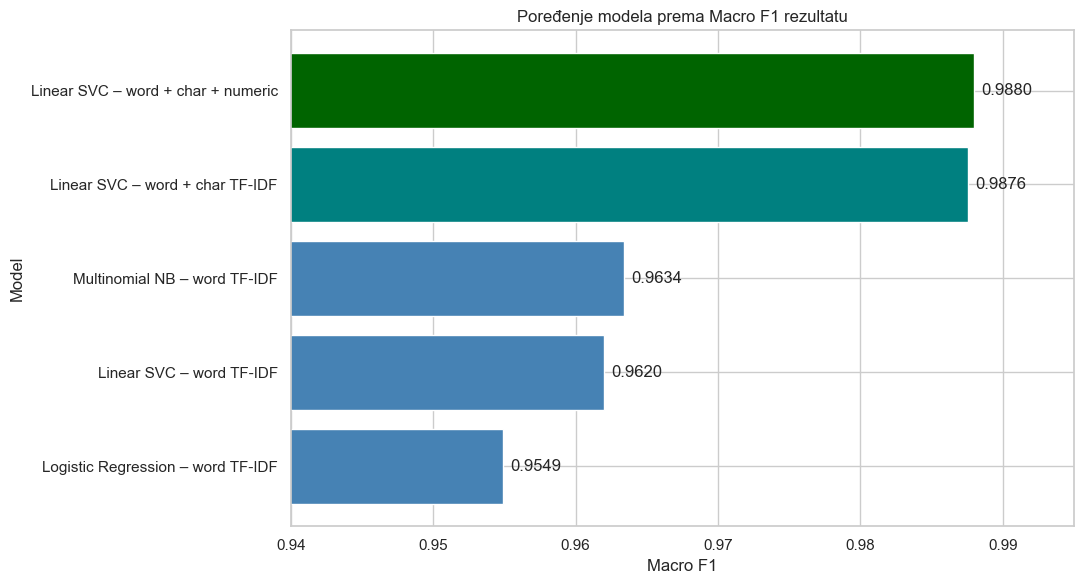

In [19]:
# Zajednička tabela rezultata
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression – word TF-IDF",
        "Linear SVC – word TF-IDF",
        "Multinomial NB – word TF-IDF",
        "Linear SVC – word + char TF-IDF",
        "Linear SVC – word + char + numeric"
    ],
    "Accuracy": [
        logistic_accuracy,
        linear_svc_accuracy,
        naive_bayes_accuracy,
        combined_text_accuracy,
        enhanced_svc_accuracy
    ],
    "Macro F1": [
        logistic_macro_f1,
        linear_svc_macro_f1,
        naive_bayes_macro_f1,
        combined_text_macro_f1,
        enhanced_svc_macro_f1
    ],
    "Weighted F1": [
        logistic_weighted_f1,
        linear_svc_weighted_f1,
        naive_bayes_weighted_f1,
        combined_text_weighted_f1,
        enhanced_svc_weighted_f1
    ],
    "Vreme treniranja (s)": [
        logistic_training_time,
        linear_svc_training_time,
        naive_bayes_training_time,
        combined_text_training_time,
        enhanced_svc_training_time
    ]
})

model_results = (
    model_results
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Vreme treniranja (s)": "{:.2f}"
    })
)

# Grafičko poređenje Macro F1 rezultata
plot_results = model_results.sort_values("Macro F1")

plt.figure(figsize=(11, 6))

bars = plt.barh(
    plot_results["Model"],
    plot_results["Macro F1"],
    color=["steelblue", "steelblue", "steelblue", "teal", "darkgreen"]
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va="center"
    )

plt.title("Poređenje modela prema Macro F1 rezultatu")
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.xlim(0.94, 0.995)
plt.tight_layout()
plt.show()

### Zaključak poređenja modela

Najbolji rezultat ostvario je unapređeni Linear SVC model koji kombinuje TF-IDF karakteristike reči, karakterne n-grame i dodatne numeričke karakteristike:

- accuracy: 0,9880;
- macro F1: 0,9880;
- weighted F1: 0,9880.

U odnosu na osnovnu logističku regresiju, macro F1 povećan je sa 0,9549 na 0,9880. Najveći deo poboljšanja nastao je dodavanjem karakternih n-grama, koji uspešno prepoznaju oznake modela, delove reči i različite načine zapisivanja proizvoda.

Numeričke karakteristike povećale su macro F1 sa 0,9876 na 0,9880. Dobitak je mali, ali merljiv. Vreme treniranja poraslo je na približno 32 sekunde, što je i dalje prihvatljivo jer se treniranje ne izvršava prilikom svake pojedinačne predikcije.

Zbog najboljeg rezultata i prihvatljivog vremena treniranja, model `Linear SVC – word + char + numeric` izabran je kao finalno rešenje.